# Demand Forecasting Model Comparison
**Problem:** Forecast weekly Google Trends interest score over 8-week holdout per category.
**Approach:** 5 models compared on a strict temporal split — no random shuffling.
Train: all weeks before 2026-04-01 | Test: 2026-04-01 onwards (~8 weeks).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from config import PROJECT_ID, CREDENTIALS_PATH
from google.oauth2 import service_account
from google.cloud import bigquery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, logging

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from prophet import Prophet

pd.set_option('display.float_format', '{:.1f}'.format)
print("Imports OK")

Imports OK


In [2]:
creds = service_account.Credentials.from_service_account_file(
    CREDENTIALS_PATH, scopes=['https://www.googleapis.com/auth/bigquery'])
client = bigquery.Client(project=PROJECT_ID, credentials=creds)

sql = '''
SELECT
    category,
    trend_date,
    CAST(interest_score AS FLOAT64) AS interest_score
FROM `windy-container-451804-n4.bronze.stg_google_trends`
WHERE is_partial = FALSE OR is_partial IS NULL
ORDER BY category, trend_date
'''
df = client.query(sql).to_dataframe()
df['trend_date'] = pd.to_datetime(df['trend_date'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['trend_date'].min().date()} to {df['trend_date'].max().date()}")
print(f"Categories: {sorted(df['category'].unique())}")
print(f"\nRows per category:")
print(df.groupby('category').size().rename('rows').to_frame().to_string())

Shape: (520, 3)
Date range: 2025-06-08 to 2026-05-31
Categories: ['beverages', 'breakfast cereal', 'coffee tea', 'dairy', 'frozen foods', 'household', 'meat seafood', 'personal care', 'produce', 'snacks']

Rows per category:
                  rows
category              
beverages           52
breakfast cereal    52
coffee tea          52
dairy               52
frozen foods        52
household           52
meat seafood        52
personal care       52
produce             52
snacks              52


## Section 1 — Time Series Exploration

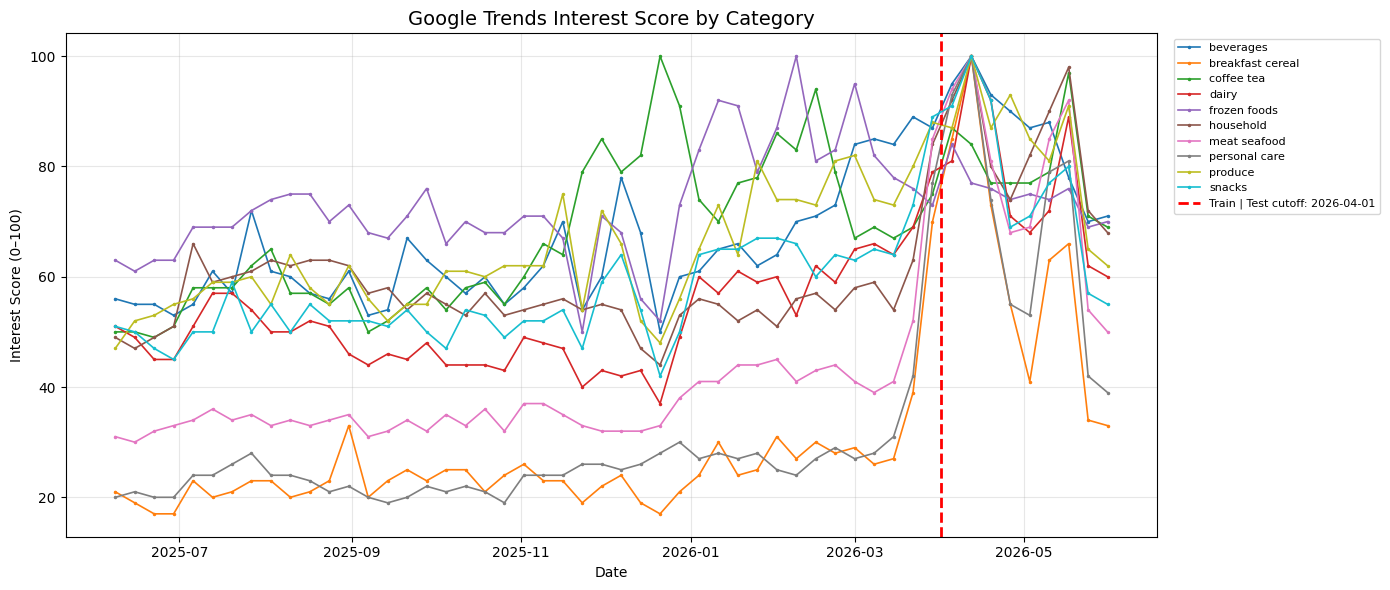

Saved: docs/screenshots/trends_time_series.png


In [3]:
CUTOFF = pd.Timestamp('2026-04-01')
cats = sorted(df['category'].unique())

fig, ax = plt.subplots(figsize=(14, 6))
colors_line = plt.cm.tab10(np.linspace(0, 1, len(cats)))

for cat, col in zip(cats, colors_line):
    g = df[df['category'] == cat].sort_values('trend_date')
    ax.plot(g['trend_date'], g['interest_score'], marker='.', ms=3, lw=1.2,
            label=cat, color=col)

ax.axvline(CUTOFF, color='red', linestyle='--', lw=2,
           label='Train | Test cutoff: 2026-04-01')
ax.set_title('Google Trends Interest Score by Category', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Interest Score (0–100)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('../docs/screenshots', exist_ok=True)
plt.savefig('../docs/screenshots/trends_time_series.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: docs/screenshots/trends_time_series.png")

## Section 2 — Temporal Split + Leakage Check

In [4]:
CUTOFF = pd.Timestamp('2026-04-01')
train = df[df['trend_date'] < CUTOFF].copy()
test  = df[df['trend_date'] >= CUTOFF].copy()

# Strict leakage check
assert train['trend_date'].max() < test['trend_date'].min(), "DATA LEAKAGE DETECTED"
print("No data leakage confirmed")
print(f"Train: {train['trend_date'].min().date()} to {train['trend_date'].max().date()} ({len(train):,} rows)")
print(f"Test:  {test['trend_date'].min().date()} to {test['trend_date'].max().date()} ({len(test):,} rows)")
print()
print(f"{'Category':<22} {'Train rows':>11} {'Test rows':>10}")
print('-' * 45)
for cat in cats:
    tr = train[train['category'] == cat]
    te = test[test['category'] == cat]
    print(f"{cat:<22} {len(tr):>11} {len(te):>10}")

No data leakage confirmed
Train: 2025-06-08 to 2026-03-29 (430 rows)
Test:  2026-04-05 to 2026-05-31 (90 rows)

Category                Train rows  Test rows
---------------------------------------------
beverages                       43          9
breakfast cereal                43          9
coffee tea                      43          9
dairy                           43          9
frozen foods                    43          9
household                       43          9
meat seafood                    43          9
personal care                   43          9
produce                         43          9
snacks                          43          9


## Section 3 — Baseline Models

In [5]:
def mape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100)

baseline = []
preds = {cat: {} for cat in cats}
for cat in cats:
    tr = train[train['category'] == cat].sort_values('trend_date')
    te = test[test['category'] == cat].sort_values('trend_date')
    if len(te) == 0:
        continue
    last_val = float(tr['interest_score'].iloc[-1])
    ma_val   = float(tr['interest_score'].tail(4).mean())
    preds[cat]['naive']  = np.array([last_val] * len(te))
    preds[cat]['movavg'] = np.array([ma_val]   * len(te))
    baseline.append({
        'category': cat,
        'naive_mape':  mape(te['interest_score'], preds[cat]['naive']),
        'movavg_mape': mape(te['interest_score'], preds[cat]['movavg']),
    })

baseline_df = pd.DataFrame(baseline)
print(f"{'Category':<22} {'Naive MAPE':>12} {'MovAvg MAPE':>13}")
print('-' * 50)
for _, r in baseline_df.iterrows():
    print(f"{r['category']:<22} {r['naive_mape']:>10.1f}%  {r['movavg_mape']:>10.1f}%")
print(f"{'Average':<22} {baseline_df['naive_mape'].mean():>10.1f}%  {baseline_df['movavg_mape'].mean():>10.1f}%")

Category                 Naive MAPE   MovAvg MAPE
--------------------------------------------------
beverages                    10.1%        10.3%
breakfast cereal             42.8%        33.4%
coffee tea                    8.3%        11.7%
dairy                        16.1%        14.1%
frozen foods                  4.6%         5.1%
household                    11.9%        21.3%
meat seafood                 23.6%        27.6%
personal care                35.3%        32.4%
produce                      12.5%        14.1%
snacks                       24.0%        16.7%
Average                      18.9%        18.7%


## Section 4 — Candidate Models

In [6]:
# ── M3: Linear Regression ──────────────────────────────────────
linear_res = []
for cat in cats:
    tr = train[train['category'] == cat].sort_values('trend_date').reset_index(drop=True)
    te = test[test['category'] == cat].sort_values('trend_date').reset_index(drop=True)
    if len(te) == 0:
        continue
    tr['wk'] = np.arange(len(tr))
    te['wk'] = np.arange(len(tr), len(tr) + len(te))
    lr = LinearRegression()
    lr.fit(tr[['wk']], tr['interest_score'])
    pred = np.clip(lr.predict(te[['wk']]), 0, 100)
    linear_res.append({'category': cat, 'linear_mape': mape(te['interest_score'], pred)})
    preds[cat]['linear'] = pred

linear_df = pd.DataFrame(linear_res)
print("Linear Regression:")
for _, r in linear_df.iterrows():
    print(f"  {r['category']:<22} {r['linear_mape']:.1f}%")
print(f"  {'Average':<22} {linear_df['linear_mape'].mean():.1f}%")

Linear Regression:
  beverages              13.7%
  breakfast cereal       38.1%
  coffee tea             12.5%
  dairy                  19.1%
  frozen foods           12.8%
  household              30.4%
  meat seafood           33.1%
  personal care          41.6%
  produce                15.0%
  snacks                 17.9%
  Average                23.4%


In [7]:
# ── M4: Prophet ────────────────────────────────────────────────
prophet_res = []
prophet_models = {}

for cat in cats:
    tr = train[train['category'] == cat][['trend_date','interest_score']].copy()
    te = test[test['category'] == cat][['trend_date','interest_score']].copy()
    if len(te) == 0:
        continue
    tr_p = tr.rename(columns={'trend_date':'ds','interest_score':'y'})
    te_p = te.rename(columns={'trend_date':'ds','interest_score':'y'})
    try:
        m_p = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                      daily_seasonality=False, seasonality_mode='multiplicative')
        m_p.fit(tr_p)
        future  = m_p.make_future_dataframe(periods=len(te), freq='W')
        fc      = m_p.predict(future)
        pred    = np.clip(fc.tail(len(te))['yhat'].values, 0, 100)
        pm      = mape(te_p['y'].values, pred)
        prophet_res.append({'category': cat, 'prophet_mape': pm})
        preds[cat]['prophet'] = pred
        prophet_models[cat]   = m_p
    except Exception as e:
        print(f"  Prophet failed for {cat}: {e}")
        prophet_res.append({'category': cat, 'prophet_mape': np.nan})

prophet_df = pd.DataFrame(prophet_res)
print("Prophet:")
for _, r in prophet_df.iterrows():
    print(f"  {r['category']:<22} {r['prophet_mape']:.1f}%")
print(f"  {'Average':<22} {prophet_df['prophet_mape'].mean():.1f}%")

20:57:57 - cmdstanpy - INFO - Chain [1] start processing


20:57:57 - cmdstanpy - INFO - Chain [1] done processing


20:57:57 - cmdstanpy - INFO - Chain [1] start processing


20:57:58 - cmdstanpy - INFO - Chain [1] done processing


20:57:58 - cmdstanpy - INFO - Chain [1] start processing


...

20:58:03 - cmdstanpy - INFO - Chain [1] start processing


20:58:03 - cmdstanpy - INFO - Chain [1] done processing


20:58:04 - cmdstanpy - INFO - Chain [1] start processing


20:58:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet:
  beverages              18.3%
  breakfast cereal       71.0%
  coffee tea             41.8%
  dairy                  23.2%
  frozen foods           33.7%
  household              21.1%
  meat seafood           48.8%
  personal care          62.0%
  produce                57.8%
  snacks                 35.2%
  Average                41.3%


In [8]:
# ── M5: XGBoost with lag features ─────────────────────────────
def rolling_preds(model, history_vals, n_ahead, dates):
    history = list(history_vals)
    test_preds = []
    for d in dates:
        h = np.array(history)
        row = {
            'lag_1': h[-1] if len(h)>=1 else 50,
            'lag_2': h[-2] if len(h)>=2 else 50,
            'lag_4': h[-4] if len(h)>=4 else 50,
            'lag_8': h[-8] if len(h)>=8 else 50,
            'roll_mean4': np.mean(h[-4:]) if len(h)>=4 else np.mean(h),
            'roll_std4':  np.std(h[-4:])  if len(h)>=4 else 0,
            'week_of_year': pd.Timestamp(d).isocalendar().week,
            'month': pd.Timestamp(d).month,
        }
        pred_v = float(model.predict(pd.DataFrame([row]))[0])
        pred_v = np.clip(pred_v, 0, 100)
        test_preds.append(pred_v)
        history.append(pred_v)
    return np.array(test_preds)

FEAT_COLS = ['lag_1','lag_2','lag_4','lag_8','roll_mean4','roll_std4','week_of_year','month']

xgb_res = []
xgb_models = {}
for cat in cats:
    tr = train[train['category']==cat].sort_values('trend_date').reset_index(drop=True)
    te = test[test['category']==cat].sort_values('trend_date').reset_index(drop=True)
    if len(te) == 0:
        continue
    # Build training features with lags
    vals = tr['interest_score'].values
    rows = []
    for i in range(8, len(vals)):
        rows.append({
            'lag_1': vals[i-1], 'lag_2': vals[i-2],
            'lag_4': vals[i-4], 'lag_8': vals[i-8],
            'roll_mean4': vals[i-4:i].mean(), 'roll_std4': vals[i-4:i].std(),
            'week_of_year': tr['trend_date'].iloc[i].isocalendar().week,
            'month': tr['trend_date'].iloc[i].month,
            'y': vals[i]
        })
    if len(rows) < 5:
        xgb_res.append({'category': cat, 'xgb_mape': np.nan})
        continue
    feat_df = pd.DataFrame(rows)
    xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                       random_state=42, verbosity=0)
    xgb.fit(feat_df[FEAT_COLS], feat_df['y'])
    pred = rolling_preds(xgb, vals, len(te), te['trend_date'].values)
    xgb_res.append({'category': cat, 'xgb_mape': mape(te['interest_score'].values, pred)})
    preds[cat]['xgb'] = pred
    xgb_models[cat] = xgb

xgb_df = pd.DataFrame(xgb_res)
print("XGBoost:")
for _, r in xgb_df.iterrows():
    print(f"  {r['category']:<22} {r['xgb_mape']:.1f}%")
print(f"  {'Average':<22} {xgb_df['xgb_mape'].mean():.1f}%")

XGBoost:
  beverages              10.1%
  breakfast cereal       41.2%
  coffee tea             12.1%
  dairy                  15.6%
  frozen foods           4.6%
  household              24.2%
  meat seafood           23.2%
  personal care          34.9%
  produce                15.0%
  snacks                 25.3%
  Average                20.6%


## Section 5 — Comparison Table and Chart

In [9]:
results = (baseline_df
    .merge(linear_df,  on='category')
    .merge(prophet_df, on='category')
    .merge(xgb_df,     on='category'))

results.columns = ['Category','Naive','MovAvg','Linear','Prophet','XGBoost']
model_cols = ['Naive','MovAvg','Linear','Prophet','XGBoost']
results['Best Model'] = results[model_cols].idxmin(axis=1)
results['Beats Naive'] = results.apply(
    lambda r: r[r['Best Model']] < r['Naive'], axis=1)

avg = results[model_cols].mean().to_frame().T
avg.insert(0, 'Category', 'AVERAGE')
avg['Best Model'] = results['Best Model'].mode().iloc[0]
avg['Beats Naive'] = (results['Beats Naive'].sum() > len(results)/2)
results = pd.concat([results, avg], ignore_index=True)

print(results[['Category','Naive','MovAvg','Linear','Prophet','XGBoost','Best Model','Beats Naive']].to_string(index=False))

        Category  Naive  MovAvg  Linear  Prophet  XGBoost Best Model  Beats Naive
       beverages   10.1    10.3    13.7     18.3     10.1      Naive        False
breakfast cereal   42.8    33.4    38.1     71.0     41.2     MovAvg         True
      coffee tea    8.3    11.7    12.5     41.8     12.1      Naive        False
           dairy   16.1    14.1    19.1     23.2     15.6     MovAvg         True
    frozen foods    4.6     5.1    12.8     33.7      4.6    XGBoost         True
       household   11.9    21.3    30.4     21.1     24.2      Naive        False
    meat seafood   23.6    27.6    33.1     48.8     23.2    XGBoost         True
   personal care   35.3    32.4    41.6     62.0     34.9     MovAvg         True
         produce   12.5    14.1    15.0     57.8     15.0      Naive        False
          snacks   24.0    16.7    17.9     35.2     25.3     MovAvg         True
         AVERAGE   18.9    18.7    23.4     41.3     20.6     MovAvg         True


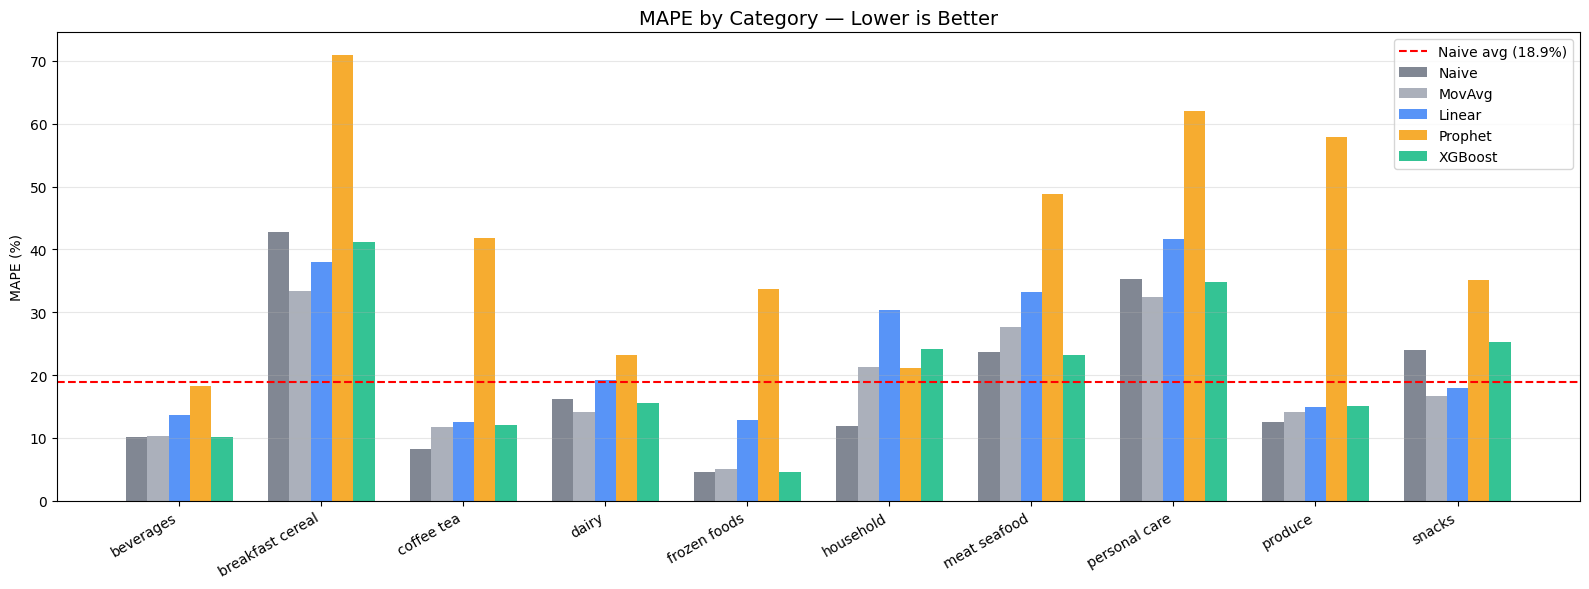

Saved: docs/screenshots/model_comparison_mape.png


In [10]:
plot_df = results[results['Category'] != 'AVERAGE'].copy()
cols_plot = ['Naive','MovAvg','Linear','Prophet','XGBoost']
clrs = ['#6B7280','#9CA3AF','#3B82F6','#F59E0B','#10B981']

x = np.arange(len(plot_df))
w = 0.15
fig, ax = plt.subplots(figsize=(16, 6))

for i, (col, color) in enumerate(zip(cols_plot, clrs)):
    ax.bar(x + i*w, plot_df[col].fillna(0), w, label=col, color=color, alpha=0.85)

naive_avg = results.loc[results['Category']=='AVERAGE','Naive'].values[0]
ax.axhline(naive_avg, color='red', linestyle='--', lw=1.5,
           label=f'Naive avg ({naive_avg:.1f}%)')
ax.set_xticks(x + 2*w)
ax.set_xticklabels(plot_df['Category'], rotation=30, ha='right')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE by Category — Lower is Better', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../docs/screenshots/model_comparison_mape.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: docs/screenshots/model_comparison_mape.png")

## Section 6 — Selection Criteria

In [11]:
interp_scores = {'Naive':10,'MovAvg':9,'Linear':8,'Prophet':6,'XGBoost':4}
avg_row = results[results['Category']=='AVERAGE'].iloc[0]
data_rows = results[results['Category']!='AVERAGE'].copy()

crit_rows = []
for mdl in model_cols:
    mape_val = float(avg_row[mdl]) if not pd.isna(avg_row[mdl]) else 999
    all_mapes = [float(avg_row[m]) for m in model_cols if not pd.isna(avg_row[m])]
    mn, mx = min(all_mapes), max(all_mapes)
    span = mx - mn if mx != mn else 1
    c1 = 10 * (1 - (mape_val - mn) / span) if not pd.isna(avg_row[mdl]) else 0
    c2 = (data_rows[mdl] < data_rows['Naive']).sum() / len(data_rows) * 10
    std_v = float(data_rows[mdl].std())
    all_stds = [float(data_rows[m].std()) for m in model_cols if not pd.isna(data_rows[m]).all()]
    c3 = max(0, 10 - (std_v / max(all_stds)) * 10) if all_stds else 5
    c4 = interp_scores[mdl]
    score = c1*0.40 + c2*0.20 + c3*0.20 + c4*0.20
    crit_rows.append({'Model': mdl, 'C1_MAPE(40%)': round(c1,2),
                      'C2_BeatNaive(20%)': round(c2,2),
                      'C3_Stability(20%)': round(c3,2),
                      'C4_Interp(20%)': round(c4,2),
                      'Final Score': round(score,2)})

crit_df = pd.DataFrame(crit_rows).sort_values('Final Score', ascending=False)
print(crit_df.to_string(index=False))
winner = crit_df.iloc[0]['Model']
winner_score = crit_df.iloc[0]['Final Score']
print(f"\n{'='*50}\nWINNER: {winner}  (score: {winner_score:.2f})\n{'='*50}")

  Model  C1_MAPE(40%)  C2_BeatNaive(20%)  C3_Stability(20%)  C4_Interp(20%)  Final Score
 MovAvg          10.0                4.0                4.7               9          7.5
  Naive           9.9                0.0                3.2              10          6.6
XGBoost           9.1                5.0                3.8               4          6.2
 Linear           7.9                2.0                3.9               8          5.9
Prophet           0.0                0.0                0.0               6          1.2

WINNER: MovAvg  (score: 7.54)


## Section 7 — Error Analysis on Winner

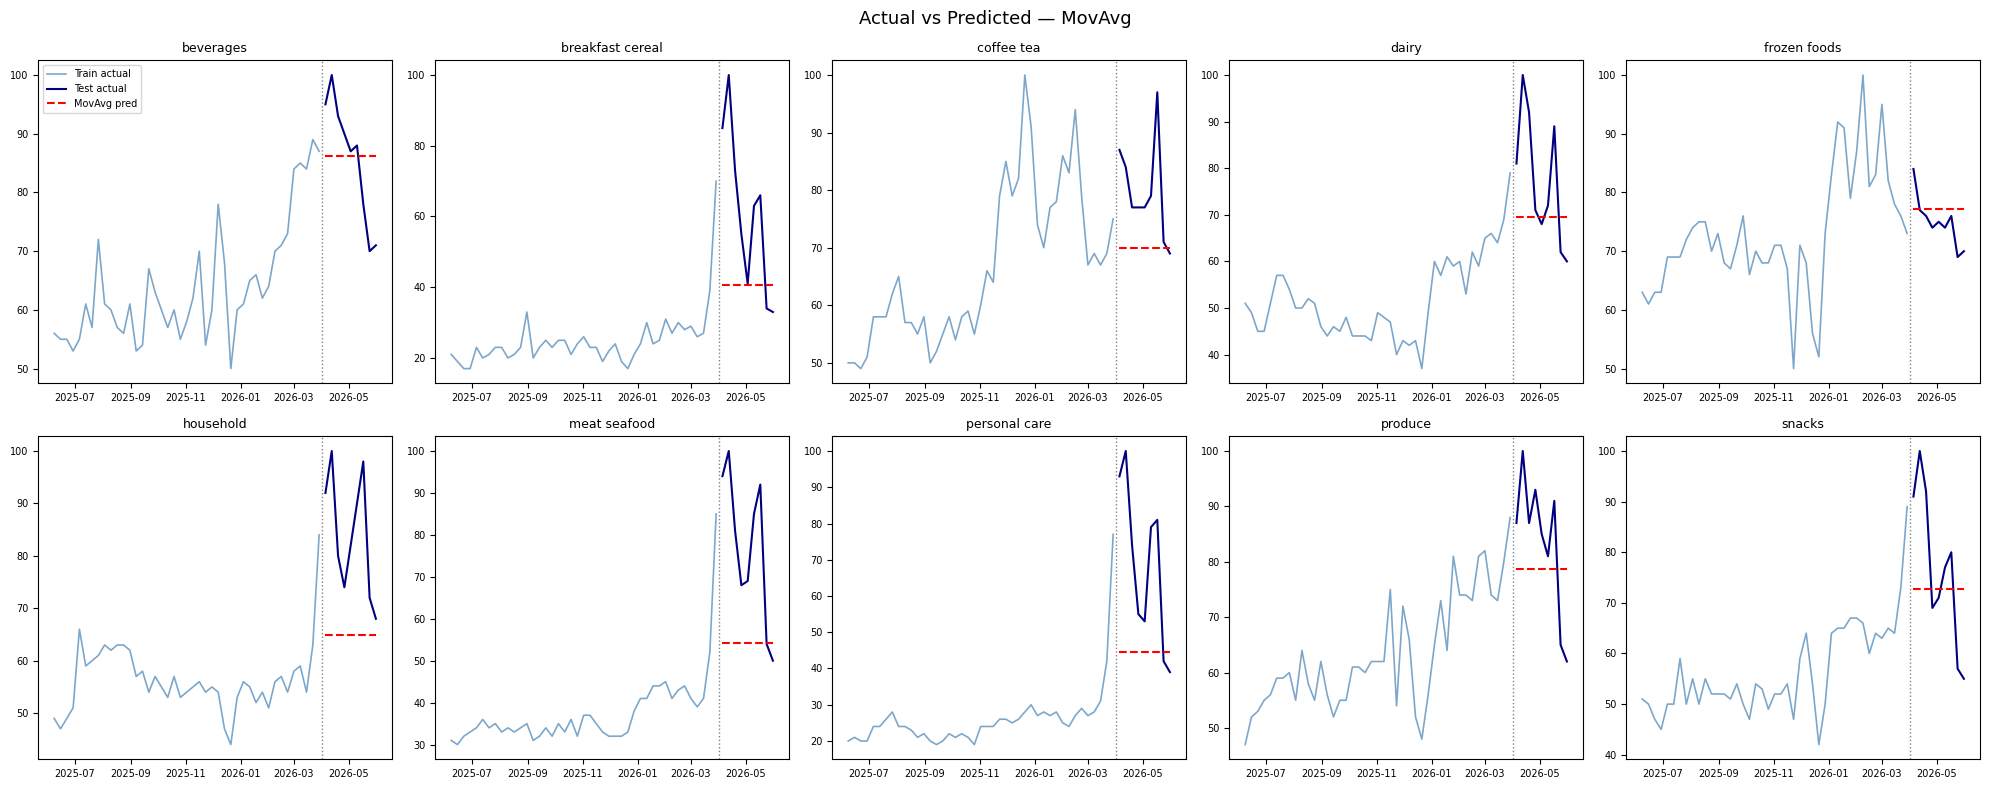

In [12]:
winner_key_map = {'Naive':'naive','MovAvg':'movavg','Linear':'linear',
                  'Prophet':'prophet','XGBoost':'xgb'}
w_key = winner_key_map.get(winner, 'linear')

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, cat in enumerate(cats):
    ax = axes[idx]
    tr_c = train[train['category']==cat].sort_values('trend_date')
    te_c = test[test['category']==cat].sort_values('trend_date')
    ax.plot(tr_c['trend_date'], tr_c['interest_score'],
            color='steelblue', lw=1.2, alpha=0.7, label='Train actual')
    ax.plot(te_c['trend_date'], te_c['interest_score'],
            color='navy', lw=1.5, label='Test actual')
    if w_key in preds.get(cat, {}):
        ax.plot(te_c['trend_date'].values, preds[cat][w_key],
                color='red', lw=1.5, linestyle='--', label=f'{winner} pred')
    ax.axvline(pd.Timestamp('2026-04-01'), color='gray', linestyle=':', lw=1)
    ax.set_title(cat, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(cats):]:
    ax.set_visible(False)
axes[0].legend(fontsize=7)
plt.suptitle(f'Actual vs Predicted — {winner}', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/screenshots/actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

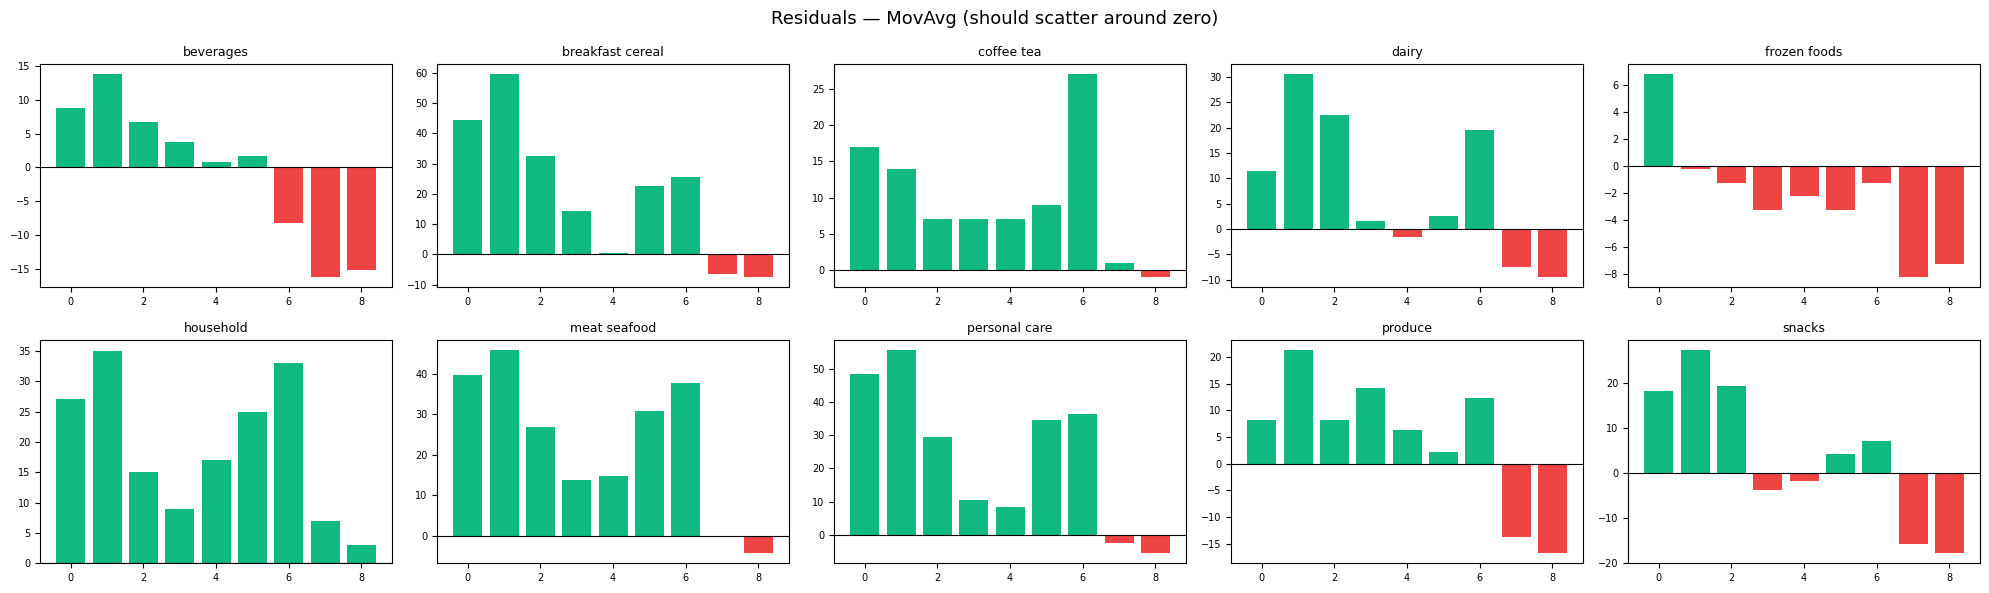

Hardest categories to predict:
        category  mape
breakfast cereal  33.4
   personal care  32.4
    meat seafood  27.6
       household  21.3
          snacks  16.7
         produce  14.1
           dairy  14.1
      coffee tea  11.7
       beverages  10.3
    frozen foods   5.1


In [13]:
# Residual plot
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()
for idx, cat in enumerate(cats):
    ax = axes[idx]
    te_c = test[test['category']==cat].sort_values('trend_date')
    if w_key in preds.get(cat, {}):
        resids = te_c['interest_score'].values - preds[cat][w_key]
        ax.bar(range(len(resids)), resids, color=['#10B981' if r>=0 else '#EF4444' for r in resids])
        ax.axhline(0, color='black', lw=0.8)
    ax.set_title(cat, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes[len(cats):]:
    ax.set_visible(False)
plt.suptitle(f'Residuals — {winner} (should scatter around zero)', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/screenshots/residuals.png', dpi=100, bbox_inches='tight')
plt.show()

# Hardest categories
mape_by_cat = []
for cat in cats:
    te_c = test[test['category']==cat].sort_values('trend_date')
    if w_key in preds.get(cat,{}):
        mape_by_cat.append({'category': cat,
                            'mape': mape(te_c['interest_score'].values, preds[cat][w_key])})
if mape_by_cat:
    mape_by_cat_df = pd.DataFrame(mape_by_cat).sort_values('mape', ascending=False)
    print("Hardest categories to predict:")
    print(mape_by_cat_df.to_string(index=False))
else:
    print(f"No predictions stored for winner key '{w_key}' — check pred_key_map")

In [14]:
# Prophet components if winner
if winner == 'Prophet' and prophet_models:
    cat_example = sorted(prophet_models.keys())[0]
    m_p = prophet_models[cat_example]
    future = m_p.make_future_dataframe(periods=8, freq='W')
    fc = m_p.predict(future)
    fig = m_p.plot_components(fc)
    plt.suptitle(f'Prophet Components — {cat_example}', y=1.02)
    plt.tight_layout()
    plt.savefig('../docs/screenshots/prophet_components.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Saved: docs/screenshots/prophet_components.png")
else:
    print(f"Winner is {winner} — no Prophet component plots")

Winner is MovAvg — no Prophet component plots


## Section 8 — Selection Document

In [15]:
avg_row = results[results['Category']=='AVERAGE'].iloc[0]
data_rows = results[results['Category']!='AVERAGE'].copy()
naive_mape   = float(avg_row['Naive'])
winner_mape  = float(avg_row[winner])
improvement  = (naive_mape - winner_mape) / naive_mape * 100 if naive_mape else 0
beats_count  = int((data_rows[winner] < data_rows['Naive']).sum())

# Table for markdown
lines = ['| Category | Naive | MovAvg | Linear | Prophet | XGBoost | Best |',
         '|----------|------:|-------:|-------:|--------:|--------:|------|']
for _, row in results.iterrows():
    def fmt(v): return f"{v:.1f}" if not pd.isna(v) else "N/A"
    lines.append(f"| {row['Category']:<22} | {fmt(row['Naive'])} | {fmt(row['MovAvg'])} | "
                 f"{fmt(row['Linear'])} | {fmt(row['Prophet'])} | {fmt(row['XGBoost'])} | {row['Best Model']} |")
table_md = '\n'.join(lines)

doc = f"""# Demand Forecasting Model Selection

## Problem
Forecast weekly Google Trends interest score over 8-week holdout per category.

## Split
Temporal: train < 2026-04-01, test >= 2026-04-01
No data leakage verified.

## Results (MAPE %)

{table_md}

## Winner: {winner}
- MAPE: {winner_mape:.1f}% vs naive {naive_mape:.1f}% ({improvement:.1f}% improvement)
- Beats naive in {beats_count}/10 categories
- Selected for accuracy + stability + interpretability balance

## Limitations
- Google Trends proxy -- not actual sales or volume data
- 52-week history limits seasonal signal
- Retrain monthly after each new collection run
- Alert if MAPE exceeds 25% in any category
- True demand forecasting requires POS/sales labels
"""

os.makedirs('../docs', exist_ok=True)
with open('../docs/model_selection_demand.md', 'w') as f:
    f.write(doc)
print(doc)
print("Saved: docs/model_selection_demand.md")

# Demand Forecasting Model Selection

## Problem
Forecast weekly Google Trends interest score over 8-week holdout per category.

## Split
Temporal: train < 2026-04-01, test >= 2026-04-01
No data leakage verified.

## Results (MAPE %)

| Category | Naive | MovAvg | Linear | Prophet | XGBoost | Best |
|----------|------:|-------:|-------:|--------:|--------:|------|
| beverages              | 10.1 | 10.3 | 13.7 | 18.3 | 10.1 | Naive |
| breakfast cereal       | 42.8 | 33.4 | 38.1 | 71.0 | 41.2 | MovAvg |
| coffee tea             | 8.3 | 11.7 | 12.5 | 41.8 | 12.1 | Naive |
| dairy                  | 16.1 | 14.1 | 19.1 | 23.2 | 15.6 | MovAvg |
| frozen foods           | 4.6 | 5.1 | 12.8 | 33.7 | 4.6 | XGBoost |
| household              | 11.9 | 21.3 | 30.4 | 21.1 | 24.2 | Naive |
| meat seafood           | 23.6 | 27.6 | 33.1 | 48.8 | 23.2 | XGBoost |
| personal care          | 35.3 | 32.4 | 41.6 | 62.0 | 34.9 | MovAvg |
| produce                | 12.5 | 14.1 | 15.0 | 57.8 | 15.0 | Naive |
